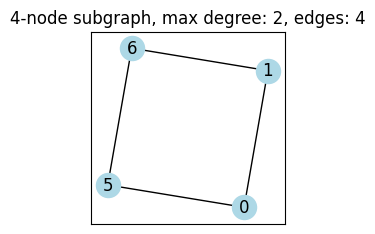

In [14]:
#the labeling of the nodes isn't important, just important that they are sequentially

## Training

so the pipeline is first converting the images to coupling map lists? and then training?

In [ ]:
from qiskit_gym.envs import LinearFunctionGym
from qiskit_gym.rl import RLSynthesis, PPOConfig, BasicPolicyConfig
from qiskit.transpiler import CouplingMap
import torch
from safetensors.torch import save_file

cmap = CouplingMap([[0,1], [0,2], [1,3], [2,3]])  # linear_function_4qL_2_square.json (config file)
env = LinearFunctionGym.from_coupling_map(cmap)

# Set up RL synthesis with PPO
rls = RLSynthesis(env, PPOConfig(), BasicPolicyConfig())

# Train the agent
rls.learn(tb_path="runs/linear_4qL_2_square/") # automatically saves the safetensors under best
#highest difficulty 256, run till infinity, stop manually (agentic stuff)
#if reward is increasing after it has reached the mx difficulty, then you can train more and more
#if the reward is not increasing anymore, you can stop

#rls.save("linear_function_4qL_2_square.json", "linear_function_4qL_2_square.safetensors")

2026-04-10 14:28:08.795 | INFO     | twisterl.rl.algorithm:learn:177 - (1/0) {'successes': {'ppo_deterministic': 0.0, 'ppo_10': 0.6299999952316284}, 'rewards': {'ppo_deterministic': -0.02524999901652336, 'ppo_10': 0.609699010848999}, 'difficulty': 1, 'success': 0.0, 'reward': -0.02524999901652336} | {'to_rust': 0.003396375, 'eval_ppo_deterministic': 0.001583584, 'eval_ppo_10': 0.007161875, 'collect': 0.00922125, 'data_to_torch': 0.0072865, 'train': 0.110804125, 'total': 0.139822583}
2026-04-10 14:28:08.799 | INFO     | twisterl.rl.algorithm:learn:197 - (1/0) Improved, saved checkpoint!
2026-04-10 14:28:08.924 | INFO     | twisterl.rl.algorithm:learn:177 - (1/1) {'successes': {'ppo_deterministic': 0.09000000357627869, 'ppo_10': 0.7300000190734863}, 'rewards': {'ppo_deterministic': 0.0707089975476265, 'ppo_10': 0.7084869146347046}, 'difficulty': 1, 'success': 0.09000000357627869, 'reward': 0.0707089975476265} | {'to_rust': 0.002653041, 'eval_ppo_deterministic': 0.000956125, 'eval_ppo_10'

In [ ]:
state_dict = torch.load("linear_function_4qL_2_square.safetensors", map_location="cpu")
save_file(state_dict, "linear_function_4qL_2_square.safetensors")
#executing from terminal saves in safetensors?
#they have another function to save in safetensors

## Synthesis

In [1]:
# for k, subgraph_list in unique_subgraphs.items():
#     for i, sg in enumerate(subgraph_list):
#         name = f"linear_function_{k}q_{i}"
#         print(f"Training {name}...")

#         edges = list(sg.edges())
#         cmap = CouplingMap(edges)
#         env = LinearFunctionGym.from_coupling_map(cmap)

#         rls = RLSynthesis(env, PPOConfig(), BasicPolicyConfig())
#         rls.learn(num_iterations=100, tb_path=f"runs/{name}/")
#         rls.save(f"models/{name}.json", f"models/{name}.safetensors")

#         print(f"Saved {name}")


In [6]:
import shutil
shutil.copy(
    "runs/linear_4qL_2_square/checkpoint_best.safetensors",
    "linear_function_4qL_2_square.safetensors"
)

'linear_function_4qL_2_square.safetensors'

## Test

In [10]:
# Use the trained model to synthesize circuits
from qiskit_gym.rl import RLSynthesis
from twisterl.utils import pull_hub_algorithm
from qiskit.circuit.library import LinearFunction
from qiskit.synthesis.linear.linear_matrix_utils import random_invertible_binary_matrix
from qiskit import QuantumCircuit


# Load the trained model
# local_path = pull_hub_algorithm(
#     repo_id="DuruTo/ai-transpiler_linear-functions",
#     model_path="./models",
#     revision="main",
#     validate=True
# )
rls = RLSynthesis.from_config_json(
    "square_lattice_configs/linear_function_6qX.json",
    "square_lattice_models/linear_function_6qX.safetensors"
)
n = rls.env.config["num_qubits"]
matrix = random_invertible_binary_matrix(n, seed=42)
input_lf = LinearFunction(matrix)
qc = rls.synth(input_lf, num_searches=100, deterministic=False)
print(qc)

qc_input = QuantumCircuit(n)
qc_input.append(input_lf, range(n))
print(qc_input.decompose().draw('text'))


     ┌───┐                                   ┌───┐                         »
q_0: ┤ X ├─────────────────■──────────────■──┤ X ├─────────────────────────»
     └─┬─┘                 │  ┌───┐       │  └─┬─┘     ┌───┐               »
q_1: ──┼──────────────■────┼──┤ X ├───────┼────┼───────┤ X ├───────────────»
       │            ┌─┴─┐┌─┴─┐└─┬─┘┌───┐┌─┴─┐  │       └─┬─┘┌───┐          »
q_2: ──■────■────■──┤ X ├┤ X ├──■──┤ X ├┤ X ├──■────■────■──┤ X ├──■────■──»
          ┌─┴─┐  │  └───┘├───┤     └─┬─┘└───┘     ┌─┴─┐     └─┬─┘┌─┴─┐  │  »
q_3: ─────┤ X ├──┼────■──┤ X ├──■────┼────────────┤ X ├───────■──┤ X ├──┼──»
          └───┘  │  ┌─┴─┐└─┬─┘┌─┴─┐  │            └───┘          └───┘  │  »
q_4: ────────────┼──┤ X ├──■──┤ X ├──┼──────────────────────────────────┼──»
               ┌─┴─┐└───┘     └───┘  │                                ┌─┴─┐»
q_5: ──────────┤ X ├─────────────────■────────────────────────────────┤ X ├»
               └───┘                                                  └───┘»

In [11]:
print(LinearFunction(qc) == LinearFunction(qc_input.decompose()))
if LinearFunction(qc) == LinearFunction(qc_input.decompose()):
    print("Input and output circuits are identical up to global phase")


True
Input and output circuits are identical up to global phase


In [ ]:
# can also compare with qiskit (equivalent to do lf synthesis), check the number of 2q gates

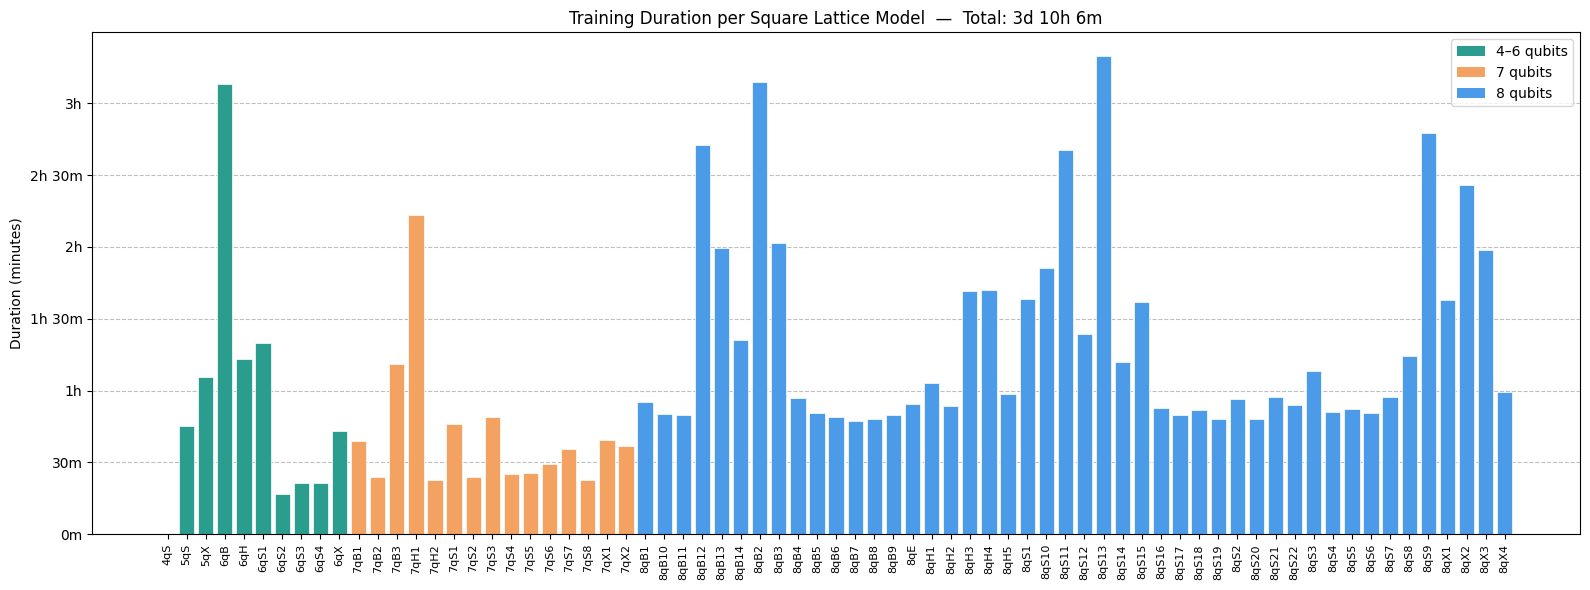

In [71]:
import os
import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

models_dir = "square_lattice_models"
files = sorted(
    [(f[:-len(".safetensors")], os.path.getmtime(os.path.join(models_dir, f)))
     for f in os.listdir(models_dir) if f.endswith(".safetensors")],
    key=lambda x: x[1]
)

names = [f[0] for f in files]
durations = [0] + [int(files[i][1] - files[i-1][1]) / 60 for i in range(1, len(files))]
colors = ["#4C9BE8" if "8q" in n else "#F4A261" if "7q" in n else "#2A9D8F" for n in names]

total = sum(durations)
td, rem = int(total // (60 * 24)), int(total % (60 * 24))
th, tm = int(rem // 60), int(rem % 60)
parts = ([f"{td}d"] if td else []) + ([f"{th}h"] if th else []) + ([f"{tm}m"] if tm or (not td and not th) else [])
total_str = " ".join(parts)

fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(range(len(names)), durations, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.replace("linear_function_", "") for n in names], rotation=90, fontsize=8)
ax.set_ylabel("Duration (minutes)")
ax.set_title(f"Training Duration per Square Lattice Model  —  Total: {total_str}")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2A9D8F", label="4–6 qubits"),
    Patch(facecolor="#F4A261", label="7 qubits"),
    Patch(facecolor="#4C9BE8", label="8 qubits"),
]
ax.legend(handles=legend_elements)
def format_hours(x, _):
    h = int(x // 60)
    m = int(x % 60)
    if h == 0:
        return f"{m}m"
    elif m == 0:
        return f"{h}h"
    else:
        return f"{h}h {m}m"

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_hours))
ax.yaxis.set_major_locator(ticker.MultipleLocator(30))
ax.yaxis.grid(True, linestyle='--', alpha=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


/var/folders/09/h3qq95w96xn1yknxjv71z0rm0000gn/T/ipykernel_56637/2596587835.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(len(model_names), 1))


Saved to results/plot_training/training_8q.png


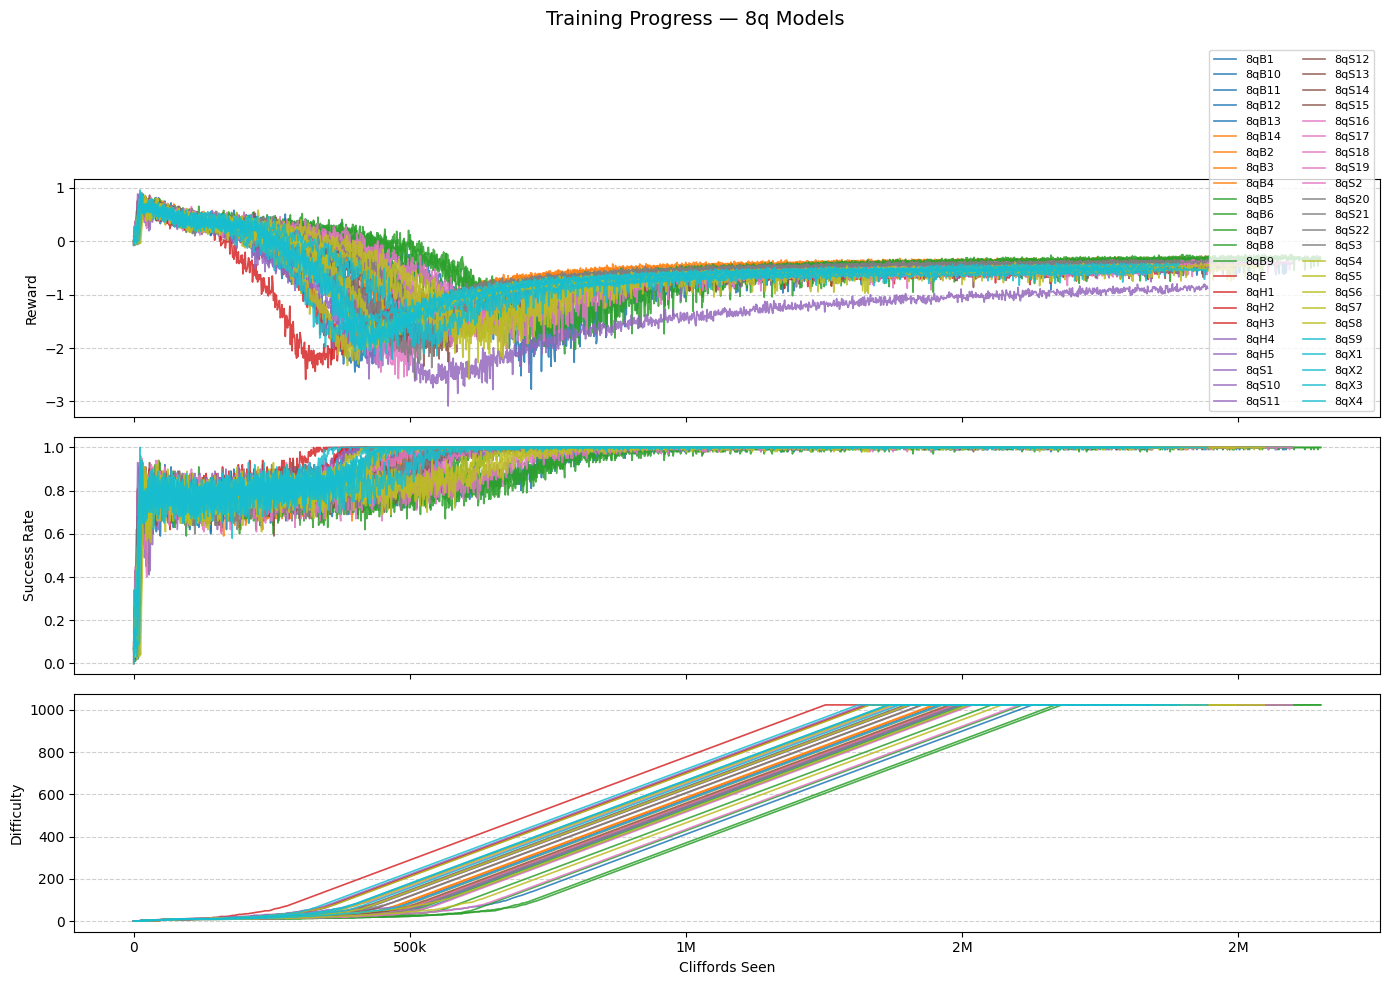

In [77]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

RUNS_DIR = "runs"
EPISODES_PER_STEP = 1024  # num_episodes in collecting config

# ── Change this to any qubit count you want ──
NUM_QUBITS = 8
# ─────────────────────────────────────────────

def load_run(run_path, tags):
    ea = EventAccumulator(run_path, size_guidance={"tensors": 0})
    ea.Reload()
    result = {}
    for tag in tags:
        try:
            events = ea.Tensors(tag)
        except KeyError:
            continue
        steps = [e.step for e in events]
        vals  = [e.tensor_proto.float_val[0] for e in events]
        global_steps = []
        offset = 0
        for i, s in enumerate(steps):
            if i > 0 and s < steps[i - 1]:
                offset = global_steps[-1] + 1
            global_steps.append(offset + s)
        result[tag] = (np.array(global_steps) * EPISODES_PER_STEP, np.array(vals))
    return result

tags = ["Benchmark/reward", "Benchmark/success", "Benchmark/difficulty"]
labels = {
    "Benchmark/reward":     "Reward",
    "Benchmark/success":    "Success Rate",
    "Benchmark/difficulty": "Difficulty",
}

prefix = f"linear_function_{NUM_QUBITS}q"
model_names = sorted(
    d for d in os.listdir(RUNS_DIR)
    if d.startswith(prefix) and os.path.isdir(os.path.join(RUNS_DIR, d))
)

if not model_names:
    print(f"No runs found for {NUM_QUBITS}-qubit models (looked for '{prefix}*' in {RUNS_DIR}/)")
else:
    cmap = plt.cm.get_cmap("tab10", max(len(model_names), 1))

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"Training Progress — {NUM_QUBITS}q Models", fontsize=14)

    for ax, tag in zip(axes, tags):
        for i, name in enumerate(model_names):
            data = load_run(os.path.join(RUNS_DIR, name), [tag])
            if tag not in data:
                continue
            x, y = data[tag]
            ax.plot(x, y, color=cmap(i), linewidth=1.2, alpha=0.85,
                    label=name.replace("linear_function_", ""))
        ax.set_ylabel(labels[tag])
        ax.yaxis.grid(True, linestyle="--", alpha=0.6)
        ax.set_axisbelow(True)

    axes[-1].set_xlabel("Cliffords Seen")
    axes[0].legend(loc="lower right", fontsize=8, ncol=2)

    def fmt_millions(x, _):
        if x >= 1e6:
            return f"{x/1e6:.0f}M"
        elif x >= 1e3:
            return f"{x/1e3:.0f}k"
        return str(int(x))

    axes[-1].xaxis.set_major_formatter(ticker.FuncFormatter(fmt_millions))

    plt.tight_layout()
    os.makedirs("results", exist_ok=True)
    out = f"results/plot_training/training_{NUM_QUBITS}q.png"
    plt.savefig(out, dpi=150)
    print(f"Saved to {out}")
    plt.show()


## Evaluation Results

Loading: results/eval_53.csv


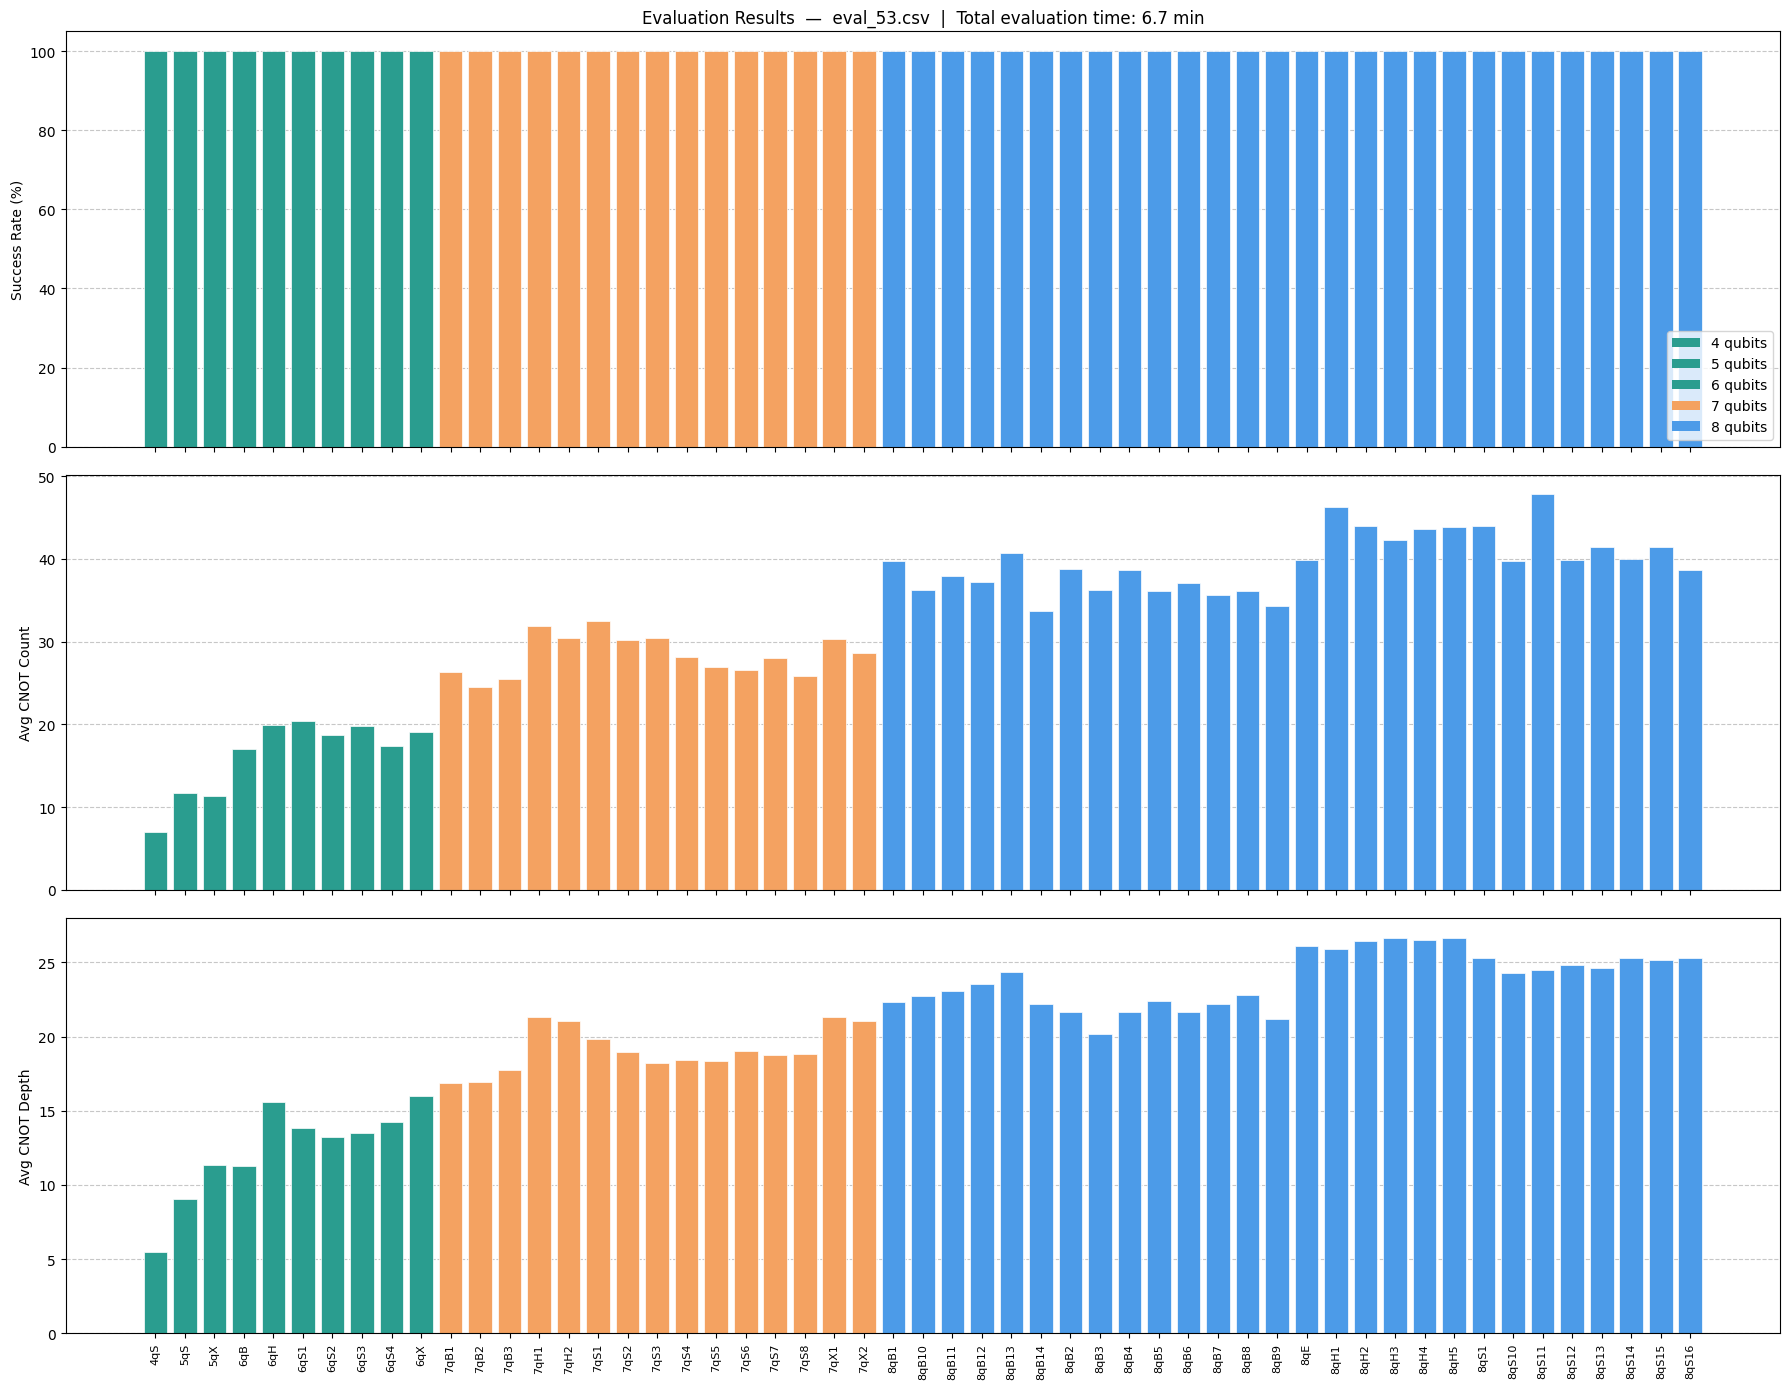

In [35]:
import os
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Load the most recent evaluation CSV
result_files = sorted(glob.glob("results/eval_*.csv"))
if not result_files:
    raise FileNotFoundError("No evaluation results found in ./results/. Run evaluate_square_lattice.py first.")
latest = result_files[-1]
print(f"Loading: {latest}")

df = pd.read_csv(latest)
df = df.sort_values(["num_qubits", "name"]).reset_index(drop=True)
short_names = df["name"].str.replace("linear_function_", "", regex=False)

# Load sidecar metadata if available
meta_path = latest.replace(".csv", "_meta.json")
duration_label = ""
if os.path.exists(meta_path):
    with open(meta_path) as f:
        meta = json.load(f)
    mins = meta["duration_seconds"] / 60
    duration_label = f"  |  Total evaluation time: {mins:.1f} min"

# Color by qubit count (matches training duration chart palette)
qubit_colors = {4: "#2A9D8F", 5: "#2A9D8F", 6: "#2A9D8F", 7: "#F4A261", 8: "#4C9BE8", 9: "#E76F51", 10: "#9B5DE5"}
colors = df["num_qubits"].map(lambda n: qubit_colors.get(n, "#999999"))

unique_qs = sorted(df["num_qubits"].unique())
legend_elements = [Patch(facecolor=qubit_colors.get(q, "#999"), label=f"{q} qubits") for q in unique_qs]

fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)
x = range(len(df))

# Success rate
axes[0].bar(x, df["success_rate"] * 100, color=colors, edgecolor="white", linewidth=0.5)
axes[0].set_ylabel("Success Rate (%)")
axes[0].set_title(f"Evaluation Results  —  {os.path.basename(latest)}{duration_label}")
axes[0].yaxis.grid(True, linestyle="--", alpha=0.7)
axes[0].set_axisbelow(True)
axes[0].set_ylim(0, 105)
axes[0].legend(handles=legend_elements, loc="lower right")

# Avg CNOT count
axes[1].bar(x, df["avg_cnots"], color=colors, edgecolor="white", linewidth=0.5)
axes[1].set_ylabel("Avg CNOT Count")
axes[1].yaxis.grid(True, linestyle="--", alpha=0.7)
axes[1].set_axisbelow(True)

# Avg CNOT depth
axes[2].bar(x, df["avg_cnot_depth"], color=colors, edgecolor="white", linewidth=0.5)
axes[2].set_ylabel("Avg CNOT Depth")
axes[2].yaxis.grid(True, linestyle="--", alpha=0.7)
axes[2].set_axisbelow(True)
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(short_names, rotation=90, fontsize=8)

plt.tight_layout()
plt.show()


## Qiskit Comparison

Loading: results/compare_qiskit_20260415_001150.csv


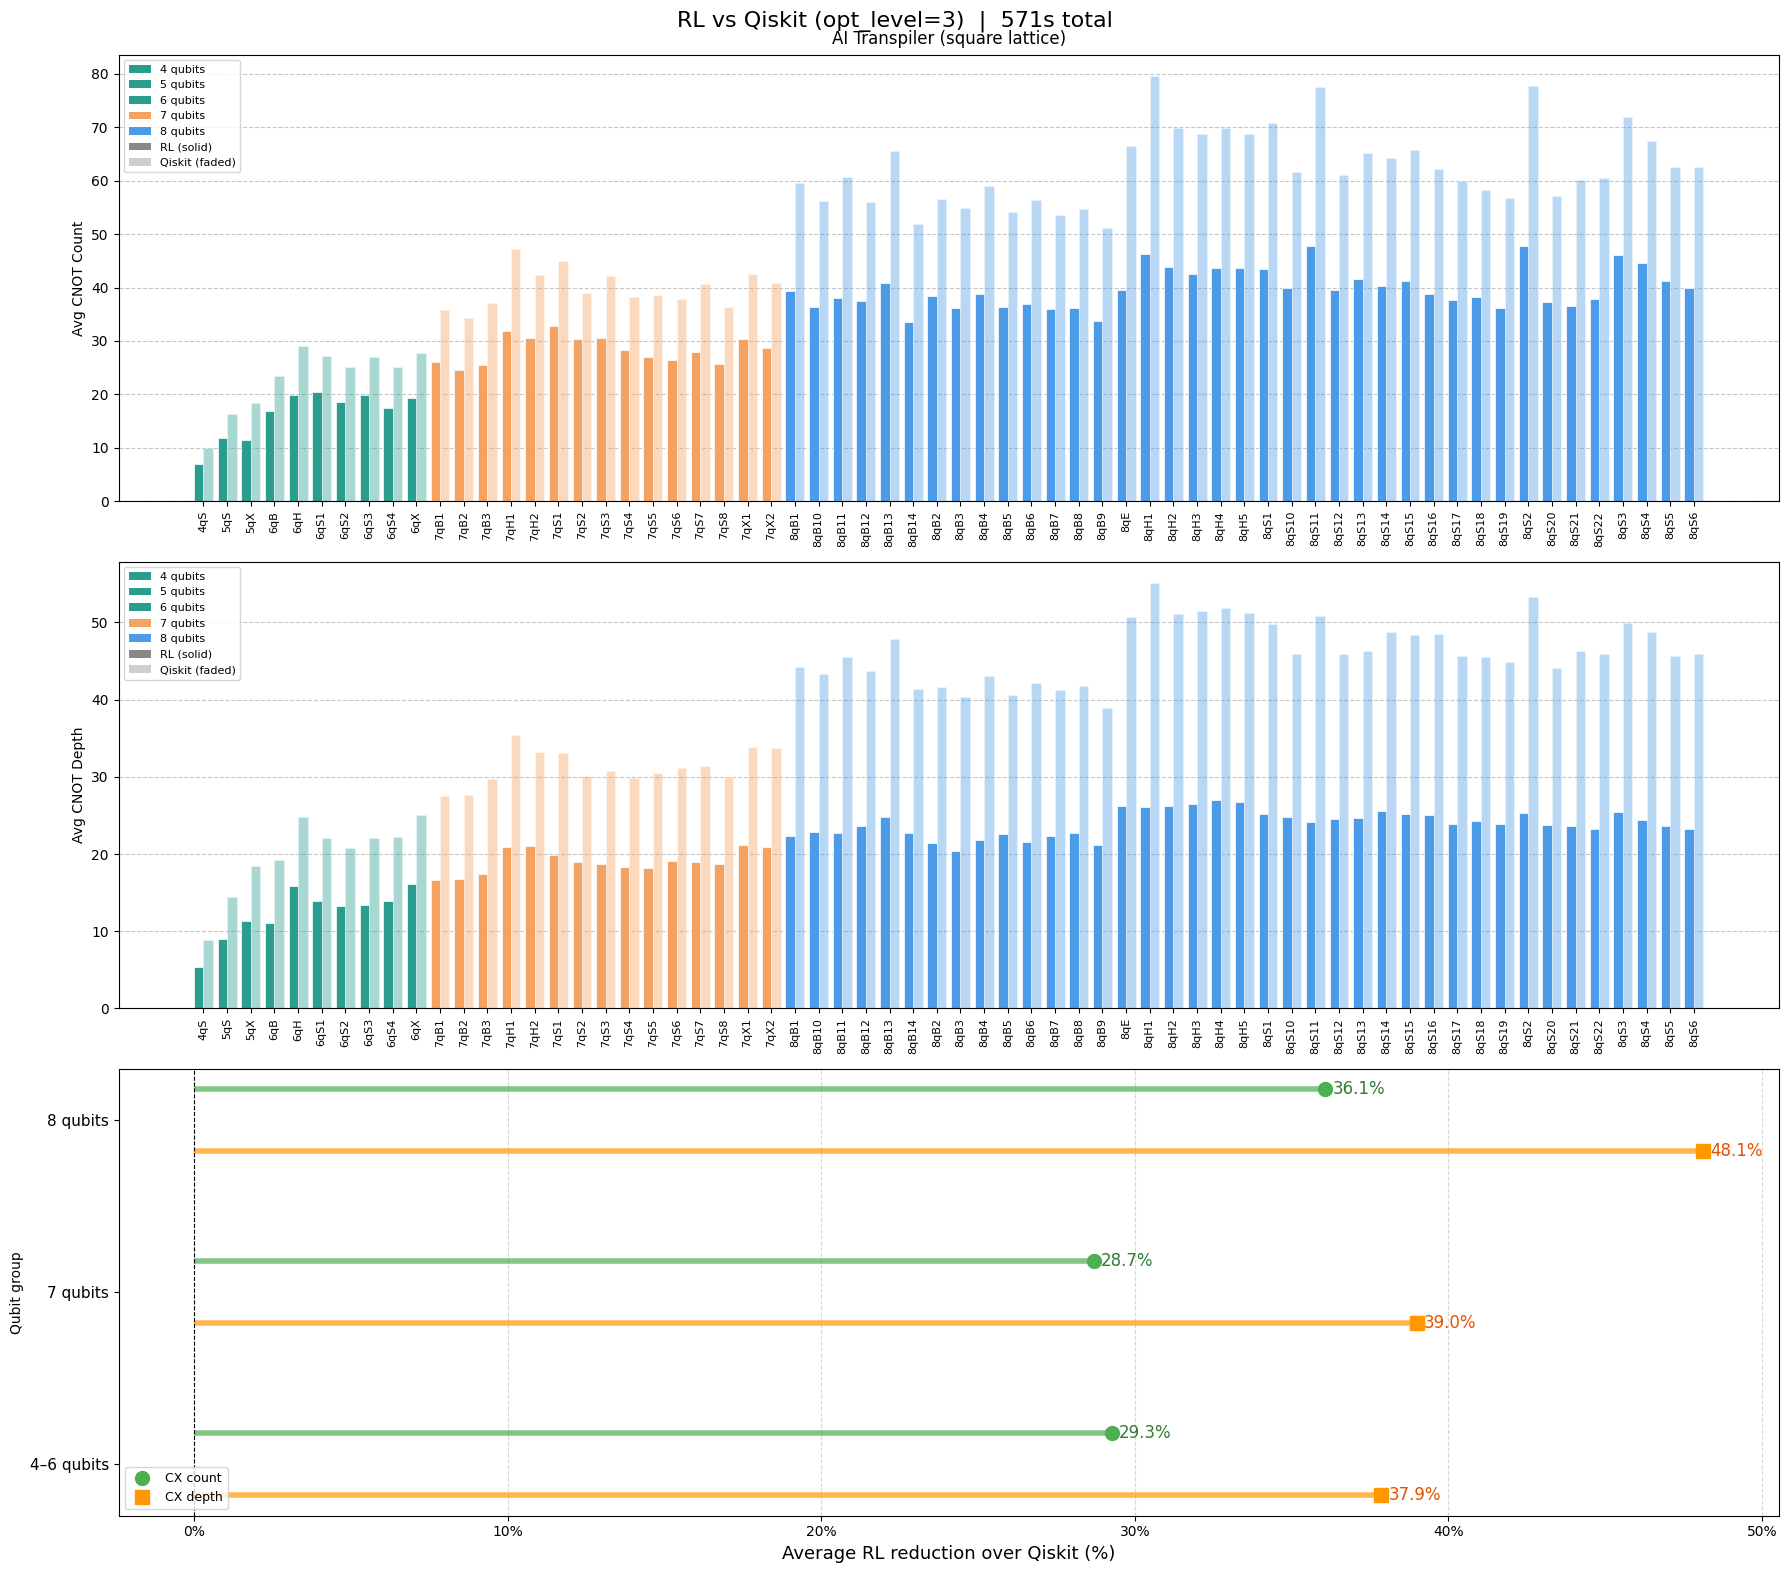


AI Transpiler (square lattice)
  Mean CX reduction:    33.3%
  Mean depth reduction: 44.4%


In [68]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from matplotlib.patches import Patch

# Load most recent comparison CSV
compare_files = sorted(glob.glob("results/compare_qiskit_*.csv"))
if not compare_files:
    raise FileNotFoundError("No comparison results found. Run compare_qiskit.py first.")
latest = compare_files[-1]
print(f"Loading: {latest}")

df_all = pd.read_csv(latest)
df_all = df_all.sort_values(["num_qubits", "name"]).reset_index(drop=True)

timestamp = df_all["timestamp"].iloc[0] if "timestamp" in df_all.columns else latest.split("compare_qiskit_")[1].replace(".csv", "")
duration = df_all["duration_seconds"].iloc[0] if "duration_seconds" in df_all.columns else float("nan")
opt_level = df_all["qiskit_opt_level"].iloc[0] if "qiskit_opt_level" in df_all.columns else "?"

# Split by source
has_source = "model_source" in df_all.columns
df_sq = df_all[df_all["model_source"] == "square_lattice"].reset_index(drop=True) if has_source else df_all
df_hh = df_all[df_all["model_source"] == "heavy_hex"].reset_index(drop=True) if has_source else pd.DataFrame()

for df in [df_sq, df_hh]:
    if df.empty:
        continue
    df["cx_reduction_pct"] = (df["qiskit_avg_cnots"] - df["rl_avg_cnots"]) / df["qiskit_avg_cnots"] * 100
    df["depth_reduction_pct"] = (df["qiskit_avg_cnot_depth"] - df["rl_avg_cnot_depth"]) / df["qiskit_avg_cnot_depth"] * 100

qubit_colors = {
    4: "#2A9D8F", 5: "#2A9D8F", 6: "#2A9D8F",
    7: "#F4A261",
    8: "#4C9BE8",
    9: "#E76F51",
    10: "#9B5DE5",
}
duration_str = f"{duration:.0f}s total" if not np.isnan(float(duration)) else ""
title = f"RL vs Qiskit (opt_level={opt_level})  |  {duration_str}"

def bar_colors(df):
    return df["num_qubits"].map(lambda n: qubit_colors.get(n, "#999999"))

def legend_elements(df):
    unique_qs = sorted(df["num_qubits"].unique())
    return [Patch(facecolor=qubit_colors.get(q, "#999"), label=f"{q} qubits") for q in unique_qs]

def plot_bars(ax, df, metric, ylabel):
    x = np.arange(len(df))
    w = 0.4
    short_names = df["name"].str.replace("linear_function_", "", regex=False)
    colors = bar_colors(df)
    ax.bar(x - w/2, df[f"rl_avg_{metric}"], width=w, color=colors, edgecolor="white", linewidth=0.5)
    ax.bar(x + w/2, df[f"qiskit_avg_{metric}"], width=w, color=colors, edgecolor="white", linewidth=0.5, alpha=0.4)
    ax.set_ylabel(ylabel)
    ax.yaxis.grid(True, linestyle="--", alpha=0.7)
    ax.set_axisbelow(True)
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, rotation=90, fontsize=8)
    ax.legend(
        handles=legend_elements(df) + [Patch(facecolor="#888", label="RL (solid)"), Patch(facecolor="#888", alpha=0.4, label="Qiskit (faded)")],
        loc="upper left", fontsize=8,
    )

def plot_lollipop(ax, df):
    # Bins are built dynamically from what's actually in the data
    unique_qs = sorted(df["num_qubits"].unique())
    if all(q <= 6 for q in unique_qs):
        bins = {"4–6 qubits": list(range(4, 7))}
    else:
        bins = {"4–6 qubits": [4, 5, 6], "7 qubits": [7], "8 qubits": [8]}
        if any(q >= 9 for q in unique_qs):
            bins["9–10 qubits"] = [9, 10]

    groups, cx_means, depth_means = [], [], []
    for label, qubits in bins.items():
        subset = df[df["num_qubits"].isin(qubits)]
        if subset.empty:
            continue
        groups.append(label)
        cx_means.append(subset["cx_reduction_pct"].mean())
        depth_means.append(subset["depth_reduction_pct"].mean())

    yg = np.arange(len(groups))
    offset = 0.18
    for i, (cx, depth) in enumerate(zip(cx_means, depth_means)):
        ax.hlines(i + offset, 0, cx, color="#4CAF50", linewidth=4, alpha=0.7)
        ax.plot(cx, i + offset, "o", color="#4CAF50", markersize=10, label="CX count" if i == 0 else "")
        ax.annotate(f"{cx:.1f}%", (cx, i + offset), xytext=(5, 0), textcoords="offset points", va="center", fontsize=12, color="#2e7d32")
        ax.hlines(i - offset, 0, depth, color="#FF9800", linewidth=4, alpha=0.7)
        ax.plot(depth, i - offset, "s", color="#FF9800", markersize=10, label="CX depth" if i == 0 else "")
        ax.annotate(f"{depth:.1f}%", (depth, i - offset), xytext=(5, 0), textcoords="offset points", va="center", fontsize=12, color="#e65100")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_yticks(yg)
    ax.set_yticklabels(groups, fontsize=11)
    ax.set_xlabel("Average RL reduction over Qiskit (%)", fontsize=13)
    ax.set_ylabel("Qubit group")
    ax.xaxis.set_major_formatter(ticker.PercentFormatter())
    ax.xaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    ax.legend(loc="lower left", fontsize=9)

n_cols = 2 if not df_hh.empty else 1
sources = [(df_sq, "AI Transpiler (square lattice)")]
if not df_hh.empty:
    sources.append((df_hh, "AI Transpiler (heavy-hex, Qiskit HF)"))

fig, axes = plt.subplots(3, n_cols, figsize=(18 * n_cols // max(n_cols, 1), 16))
if n_cols == 1:
    axes = axes.reshape(-1, 1)
fig.suptitle(title, fontsize=16)

for col, (df, source_label) in enumerate(sources):
    axes[0, col].set_title(source_label, fontsize=12, pad=8)
    plot_bars(axes[0, col], df, "cnots", "Avg CNOT Count")
    plot_bars(axes[1, col], df, "cnot_depth", "Avg CNOT Depth")
    plot_lollipop(axes[2, col], df)

plt.tight_layout()
plt.show()

for df, source_label in sources:
    print(f"\n{source_label}")
    print(f"  Mean CX reduction:    {df['cx_reduction_pct'].mean():.1f}%")
    print(f"  Mean depth reduction: {df['depth_reduction_pct'].mean():.1f}%")

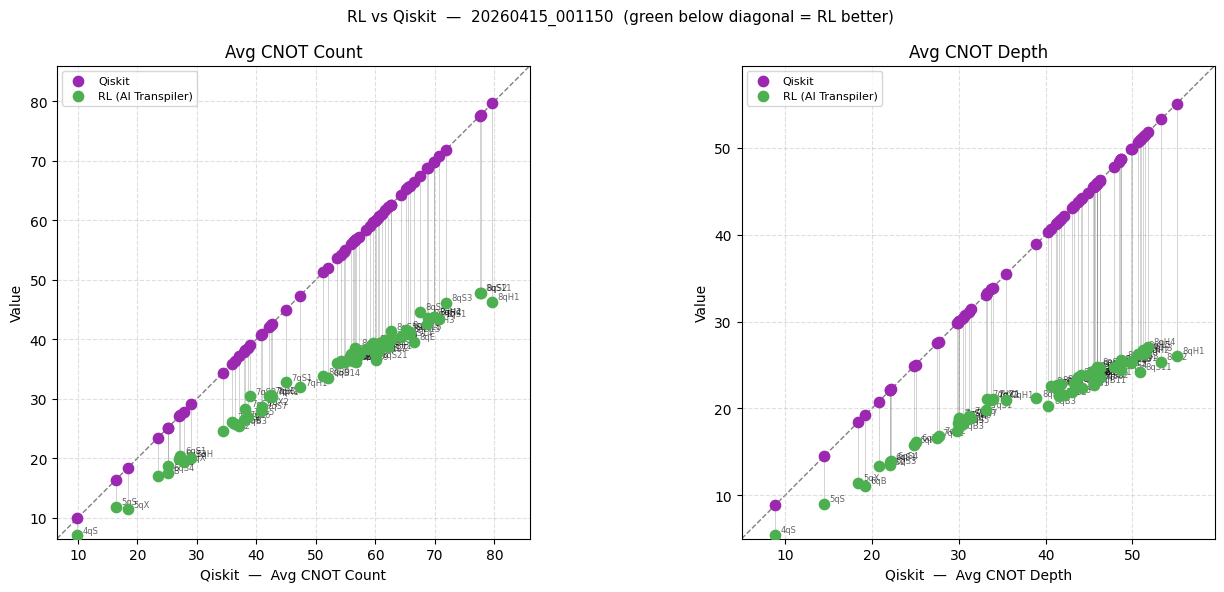

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, label in [
    (axes[0], "cnots", "Avg CNOT Count"),
    (axes[1], "cnot_depth", "Avg CNOT Depth"),
]:
    qk = df[f"qiskit_avg_{metric}"]
    rl = df[f"rl_avg_{metric}"]

    lim_max = max(qk.max(), rl.max()) * 1.08
    lim_min = min(qk.min(), rl.min()) * 0.92

    # Diagonal: y = x (no change)
    ax.plot([lim_min, lim_max], [lim_min, lim_max], color="gray", linewidth=1, linestyle="--", zorder=1)

    # Connect paired points per model
    for _, row in df.iterrows():
        ax.plot(
            [row[f"qiskit_avg_{metric}"], row[f"qiskit_avg_{metric}"]],
            [row[f"qiskit_avg_{metric}"], row[f"rl_avg_{metric}"]],
            color="gray", linewidth=0.6, alpha=0.4, zorder=2,
        )

    # Qiskit points sit ON the diagonal (x = y = qiskit value)
    ax.scatter(qk, qk, color="#9C27B0", zorder=4, label="Qiskit", s=55)
    # RL points sit at (qiskit_value, rl_value)
    ax.scatter(qk, rl, color="#4CAF50", zorder=4, label="RL (AI Transpiler)", s=55)

    # Annotate RL points with model name
    for _, row in df.iterrows():
        ax.annotate(
            row["name"].replace("linear_function_", ""),
            (row[f"qiskit_avg_{metric}"], row[f"rl_avg_{metric}"]),
            fontsize=6, alpha=0.6, xytext=(4, 2), textcoords="offset points",
        )

    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    ax.set_xlabel(f"Qiskit  —  {label}")
    ax.set_ylabel(f"Value")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.set_aspect("equal")
    ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle(f"RL vs Qiskit  —  {timestamp}  (green below diagonal = RL better)", fontsize=11)
plt.tight_layout()
plt.show()